# Imports

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Config

In [2]:
DATA_DIR = Path("/projectnb/medaihack/ABPET/data")

TRACER_NAME_MAP = {
    "FBP": "Florbetapir (AV-45)",
    "FBB": "Florbetaben",
    "PIB": "Pittsburg Compound-B",
    "NAV": "flutafuranol"
}

csv_path = '/projectnb/medaihack/ABPET/data/train.csv'

# Load training CSV

In [3]:
df = pd.read_csv(csv_path, low_memory=False)
df.columns = df.columns.str.strip()

print("Loaded CSV:", csv_path)
print("Columns:", list(df.columns))
display(df.head())

Loaded CSV: /projectnb/medaihack/ABPET/data/train.csv
Columns: ['ID', 'TRACER.AMY', 'CENTILOIDS', 'npy_path']


,ID,TRACER.AMY,CENTILOIDS,npy_path
0,B98313661,FBP,31.4398,/projectnb/medaihack/ABPET/data/npy_files/A4_B...
1,NACC097291,FBB,22.0000,/projectnb/medaihack/ABPET/data/npy_files/NACC...
2,NACC533928,FBB,-5.0000,/projectnb/medaihack/ABPET/data/npy_files/NACC...
3,NACC074386,FBP,9.0000,/projectnb/medaihack/ABPET/data/npy_files/NACC...
4,B75510302,FBP,2.1486,/projectnb/medaihack/ABPET/data/npy_files/A4_B...


# Inspect tracer counts

In [4]:
tracer_col = "TRACER.AMY"
path_col = "npy_path"

if tracer_col is None:
    raise KeyError(f"Could not find TRACER.AMY. Available columns: {list(df.columns)}")

if path_col is None:
    raise KeyError(f"Could not find npy_path. Available columns: {list(df.columns)}")

print("Using tracer column:", tracer_col)
print("Using path column:", path_col)
display(df[tracer_col].value_counts(dropna=False))

Using tracer column: TRACER.AMY
Using path column: npy_path


TRACER.AMY
FBP    946
PIB    532
FBB    454
NAV     68
Name: count, dtype: int64

# PET visualization functions

In [5]:
def load_volume(npy_full_path):
    npy_full_path = Path(npy_full_path)
    vol = np.load(npy_full_path).astype(np.float32)
    if vol.ndim == 4:
        vol = vol.squeeze(0)
    if vol.ndim != 3:
        raise ValueError(f"Expected a 3D volume, got shape {vol.shape} for {npy_full_path}")
    return vol

def get_window(vol, vmin_pct=0.0, vmax_pct=99.5):
    return float(np.percentile(vol, vmin_pct)), float(np.percentile(vol, vmax_pct))

def normalize_volume(vol, vmin, vmax):
    clipped = np.clip(vol, vmin, vmax)
    scale = vmax - vmin
    if scale < 1e-8:
        return np.zeros_like(clipped)
    return (clipped - vmin) / scale

def visualize_pet_scan(full_path, tracer_label=None, cmap="hot", vmin_pct=0.0, vmax_pct=99.5, figsize=(16, 5)):
    full_path = Path(full_path)
    if not full_path.exists():
        raise FileNotFoundError(f"File does not exist: {full_path}")

    vol = load_volume(full_path)
    vmin, vmax = get_window(vol, vmin_pct=vmin_pct, vmax_pct=vmax_pct)
    vol_norm = normalize_volume(vol, vmin, vmax)

    d, h, w = vol.shape
    axial = vol_norm[d // 2, :, :]
    coronal = vol_norm[:, h // 2, :]
    sagittal = vol_norm[:, :, w // 2]

    fig, axes = plt.subplots(1, 3, figsize=figsize, facecolor="black")
    fig.suptitle(
        f"{tracer_label or 'PET Scan'}\n{full_path.name}",
        color="white",
        fontsize=16,
        y=1.02,
    )

    slice_data = [
        ("Axial", axial, d // 2),
        ("Coronal", coronal, h // 2),
        ("Sagittal", sagittal, w // 2),
    ]

    for ax, (name, img, idx) in zip(axes, slice_data):
        ax.imshow(img, cmap=cmap, origin="lower", vmin=0, vmax=1, interpolation="bilinear")
        ax.set_title(f"{name}  (slice {idx})", color="white", fontsize=14)
        ax.axis("off")
        ax.set_facecolor("black")

    sm = ScalarMappable(cmap=cmap, norm=Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation="horizontal", fraction=0.04, pad=0.08)
    cbar.set_label("SUVR", color="white")
    cbar.ax.xaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.get_xticklabels(), color="white")

    stats = (
        f"shape={vol.shape}   "
        f"min={vol.min():.4f}   max={vol.max():.4f}   "
        f"mean={vol.mean():.4f}   std={vol.std():.4f}"
    )
    fig.text(0.5, -0.05, stats, ha="center", color="lightgray", fontsize=10, family="monospace")

    plt.tight_layout()
    plt.show()

# Sample a valid path per tracer

In [6]:
valid_df = df.dropna(subset=[tracer_col, path_col]).copy()
valid_df[path_col] = valid_df[path_col].astype(str).str.strip()
valid_df["path_exists"] = valid_df[path_col].apply(lambda p: Path(p).exists())
valid_df = valid_df[valid_df["path_exists"]].copy()

if valid_df.empty:
    raise FileNotFoundError(f"No rows with existing .npy files were found in column '{path_col}'.")

sampled_rows = (
    valid_df.groupby(tracer_col)
    .sample(1, random_state=42)
    .reset_index(drop=True)
)

sampled_rows["TRACER_NAME"] = (
    sampled_rows[tracer_col]
    .map(TRACER_NAME_MAP)
    .fillna(sampled_rows[tracer_col].astype(str))
)

print("sampled_rows columns:", list(sampled_rows.columns))
display(sampled_rows[[c for c in ["ID", tracer_col, "TRACER_NAME", "CENTILOIDS", path_col] if c in sampled_rows.columns]])

sampled_rows columns: ['ID', 'TRACER.AMY', 'CENTILOIDS', 'npy_path', 'path_exists', 'TRACER_NAME']


,ID,TRACER.AMY,TRACER_NAME,CENTILOIDS,npy_path
0,NACC172611,FBB,Florbetaben,18.0000,/projectnb/medaihack/ABPET/data/npy_files/NACC...
1,B78334488,FBP,Florbetapir (AV-45),13.1328,/projectnb/medaihack/ABPET/data/npy_files/A4_B...
2,NACC257882,NAV,flutafuranol,3.0000,/projectnb/medaihack/ABPET/data/npy_files/NACC...
3,NACC454008,PIB,Pittsburg Compound-B,11.0000,/projectnb/medaihack/ABPET/data/npy_files/NACC...


# Visualize one sampled scan per tracer


Visualizing tracer: FBB -> Florbetaben
Path: /projectnb/medaihack/ABPET/data/npy_files/NACC172611_2022-05-19_14_33_04.0_I10573139_Amyloid_NACC-PET_NACC172611.npy


/scratch/4211208.1.h200/ipykernel_3440271/284901996.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


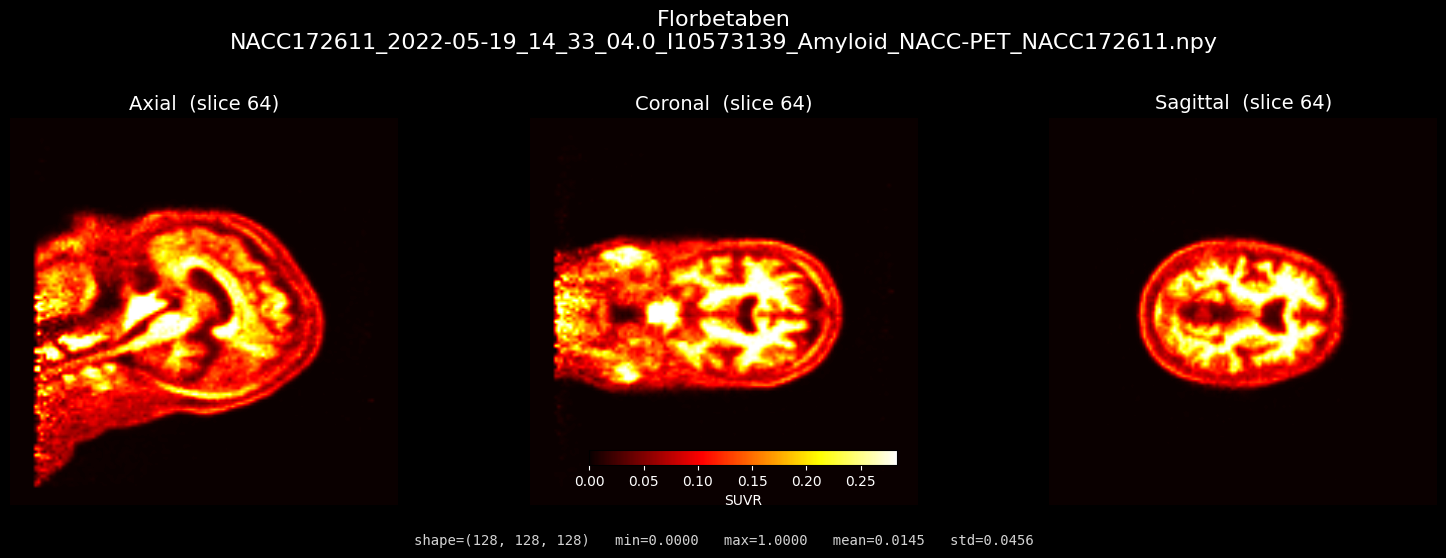


Visualizing tracer: FBP -> Florbetapir (AV-45)
Path: /projectnb/medaihack/ABPET/data/npy_files/A4_B78334488_MR_Florbetapir_Br_20210214172456217_S990118_I1410784_A4_B78334488.npy


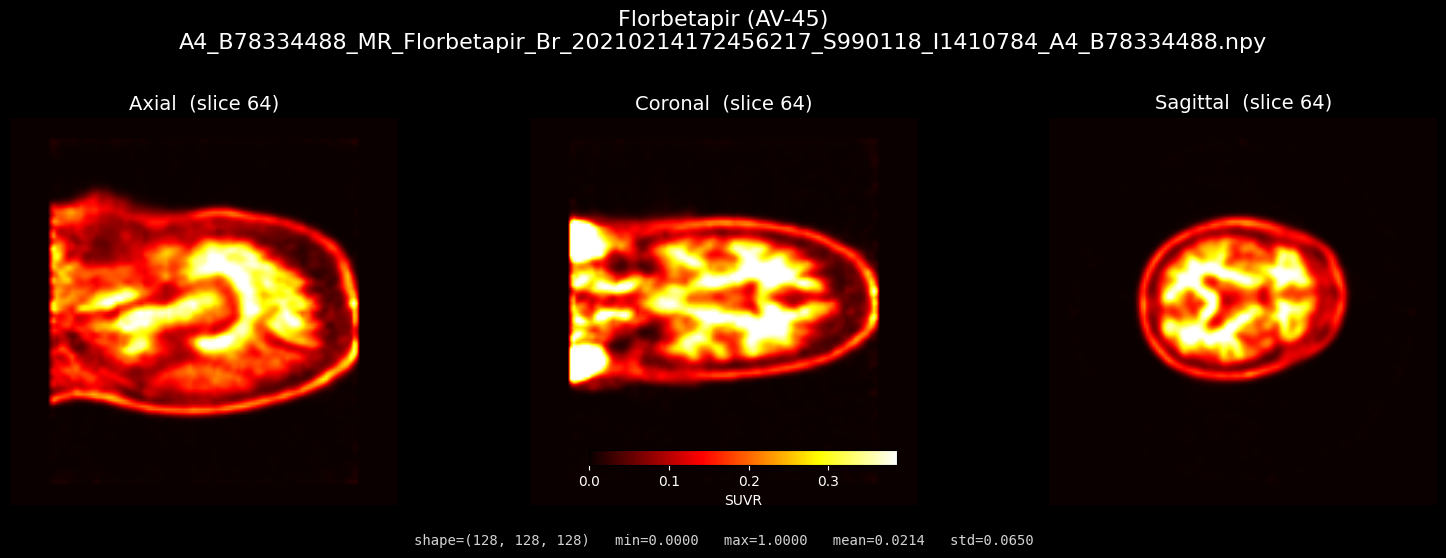


Visualizing tracer: NAV -> flutafuranol
Path: /projectnb/medaihack/ABPET/data/npy_files/NACC257882_2025-01-30_11_46_00.0_I11139535_Amyloid_NACC-PET_NACC257882.npy


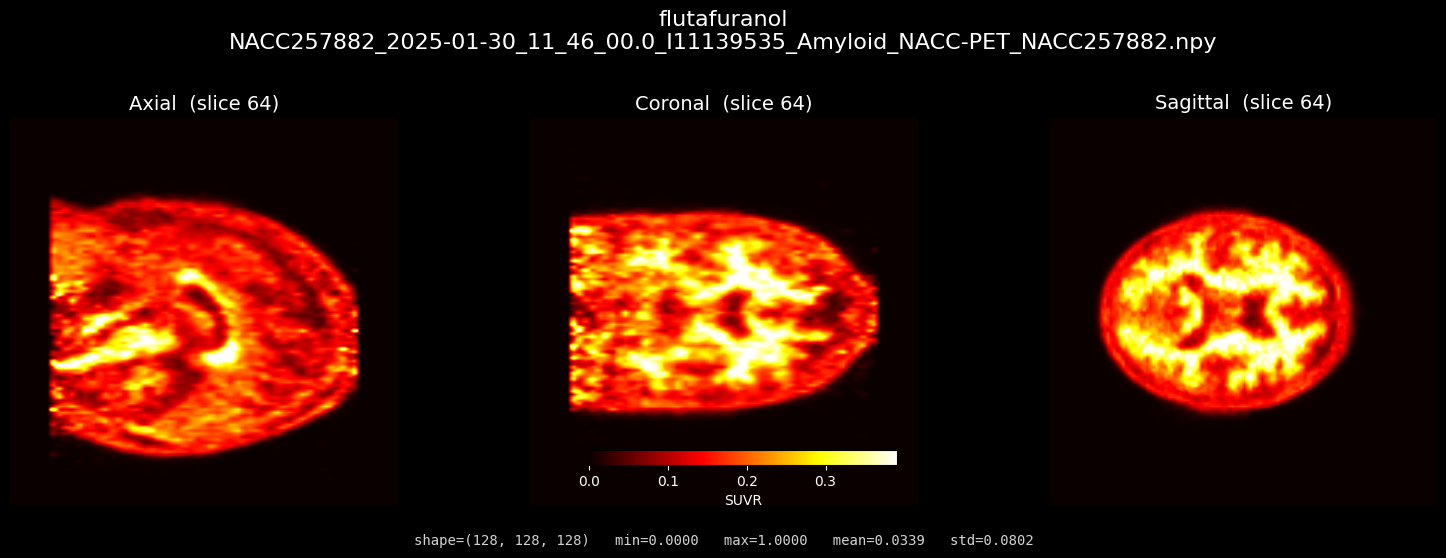


Visualizing tracer: PIB -> Pittsburg Compound-B
Path: /projectnb/medaihack/ABPET/data/npy_files/NACC454008_2023-05-12_13_32_01.0_I10952591_Amyloid_NACC-PET_NACC454008.npy


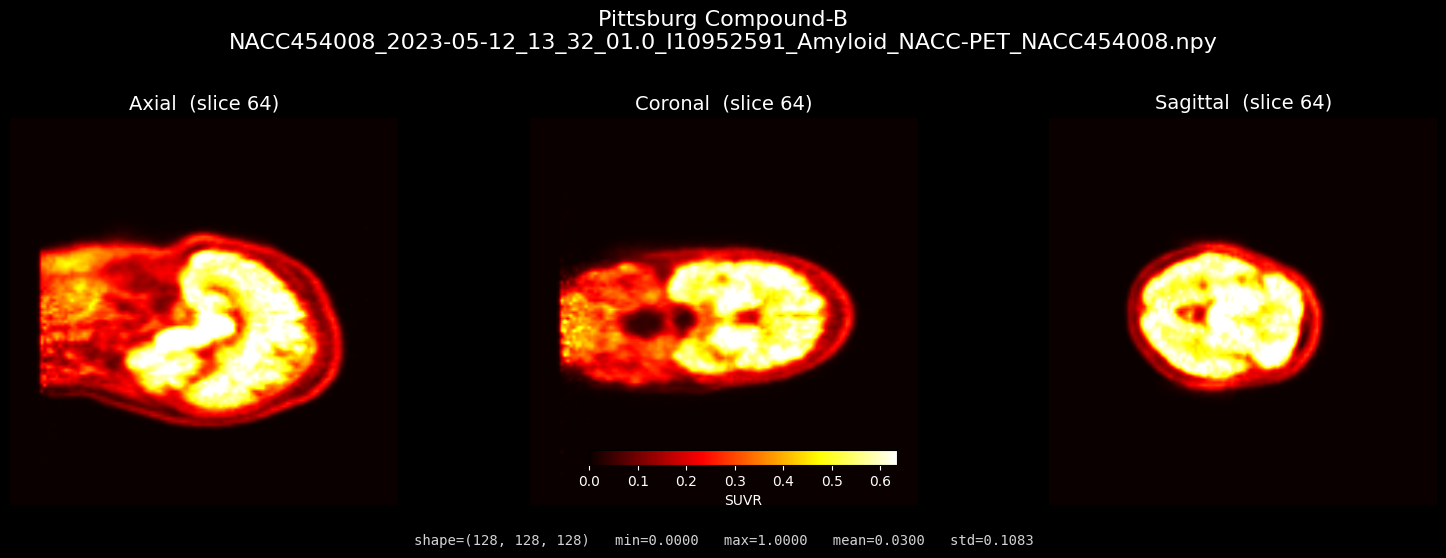

In [7]:
for _, row in sampled_rows.iterrows():
    tracer_code = row[tracer_col]
    tracer_name = row["TRACER_NAME"]
    npy_path    = row[path_col]

    print(f"\nVisualizing tracer: {tracer_code} -> {tracer_name}")
    print(f"Path: {npy_path}")

    visualize_pet_scan(
        full_path=npy_path,
        tracer_label=tracer_name,
        cmap="hot",
        vmin_pct=0.0,
        vmax_pct=99.5,
    )